# OVRO-LWA single-subband source detection

Run **PyBDSF** source detection on one frequency subband of OVRO-LWA
coadd images, then fuse detections across LST hours into one catalog.

Pipeline (library: `lwa_catalog.create` + Parquet I/O):

1. **Discover** FITS under `FITS_ROOT` matching `FITS_GLOB`.
2. **Detect** sources per image (`detect_sources`).
3. **LST merge** within the subband (`merge_lst_metacatalog`) — median-flux
   representative for sources seen in multiple hours.
4. **Visualize** the merged catalog with a corner plot.

No cross-band / global metacatalog association. Set
`REUSE_CACHED_CATALOGS = True` to skip PyBDSF / LST merge when caches exist.


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

from lwa_catalog import CatalogLayout
from lwa_catalog.constants import GAUL_COLUMNS
from lwa_catalog.create import (
    detect_sources,
    discover_fits_files,
    discovered_slots,
    lst_hours_from_discovery,
    merge_lst_metacatalog,
)
from lwa_catalog.io import (
    lst_merged_cache_complete,
    read_lst_merged,
    read_sources_catalog,
    sources_cache_complete,
    write_lst_merged,
    write_sources_catalog,
)

# --- user configuration ---------------------------------------------------
FITS_ROOT = Path(
    "/lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827"
)
FITS_GLOB: str | tuple[str, ...] = (
    "??h_18MHz/*I_deep_Taper_Robust-0.75_pbcorr*.fits"
)
OUTPUT_DIR = Path("/fast/claw/sources_18MHz")  # Parquet per-image catalogs

# PyBDSF detection parameters
BDSF_KW = dict(
    thresh="hard",
    thresh_isl=7.0,
    thresh_pix=4.0,
    atrous_do=False,
    psf_vary_do=False,
    quiet=True,
    ncores=16,
)

# Optional subset of LST hour bins (e.g. ["01h", "02h"]). None = all discovered.
LST_HOURS_OVERRIDE: list[str] | None = None

# When True, skip PyBDSF if matching Parquet files already exist
REUSE_CACHED_CATALOGS = True

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
layout = CatalogLayout(OUTPUT_DIR)


## Discover FITS

Find images under `FITS_ROOT` matching `FITS_GLOB` and parse LST hour /
subband from filenames (`lwa_catalog.create.discover`).


In [2]:
_fits_patterns = (FITS_GLOB,) if isinstance(FITS_GLOB, str) else tuple(FITS_GLOB)
fits_files = discover_fits_files(FITS_ROOT, patterns=_fits_patterns)
_discovered_lst_hours = lst_hours_from_discovery(fits_files)
LST_HOURS = (
    list(LST_HOURS_OVERRIDE)
    if LST_HOURS_OVERRIDE is not None
    else _discovered_lst_hours
)
fits_by_slot = discovered_slots(fits_files)

# Restrict to requested LST hours when an override is set
if LST_HOURS_OVERRIDE is not None:
    fits_by_slot = {
        key: meta
        for key, meta in fits_by_slot.items()
        if key[0] in LST_HOURS
    }

summary = pd.DataFrame(
    {
        "path": [m.path.name for m in fits_by_slot.values()],
        "lst_hour": [m.lst_hour for m in fits_by_slot.values()],
        "band": [m.band for m in fits_by_slot.values()],
        "time_key": [m.time_key for m in fits_by_slot.values()],
    }
)
print(
    f"Found {len(fits_by_slot)} FITS files under {FITS_ROOT} "
    f"matching {list(_fits_patterns)}"
)
print(
    f"LST hours from discovery ({len(_discovered_lst_hours)}): "
    f"{', '.join(_discovered_lst_hours)}"
)
if LST_HOURS_OVERRIDE is not None:
    print(f"LST hours in use (override): {', '.join(LST_HOURS)}")
else:
    print(f"LST hours in use (all discovered): {', '.join(LST_HOURS)}")
bands = sorted({m.band for m in fits_by_slot.values()})
print(f"Subband(s): {', '.join(bands)}")
summary.sort_values(["lst_hour", "band"]).reset_index(drop=True)


Found 22 FITS files under /lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827 matching ['??h_18MHz/*I_deep_Taper_Robust-0.75_pbcorr*.fits']
LST hours from discovery (22): 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h
LST hours in use (all discovered): 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h
Subband(s): 18MHz


,path,lst_hour,band,time_key
0,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,01h,18MHz,None
1,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,02h,18MHz,None
2,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,03h,18MHz,None
3,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,04h,18MHz,None
4,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,05h,18MHz,None
5,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,06h,18MHz,None
6,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,07h,18MHz,None
7,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,08h,18MHz,None
8,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,09h,18MHz,None
9,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,10h,18MHz,None


## PyBDSF source detection

Detect sources per image with PyBDSF (`lwa_catalog.create.detect`).
Catalogs are written as `sources_{lst}_{band}.parquet` under `OUTPUT_DIR`.


In [3]:
def all_sources_cached() -> bool:
    """True when every discovered (lst, band) slot has a sources Parquet file."""
    return sources_cache_complete(layout, sorted(fits_by_slot))


def load_sources_catalog(lst_hour: str, band: str) -> pd.DataFrame:
    """Load a per-image sources Parquet catalog, backfilling beam from the FITS image."""
    meta = fits_by_slot[(lst_hour, band)]
    return read_sources_catalog(layout, lst_hour, band, fits_path=meta.path)


def load_per_image_catalogs_from_disk() -> dict[tuple[str, str], pd.DataFrame]:
    """Load all per-image catalogs from OUTPUT_DIR when every slot is cached."""
    catalogs: dict[tuple[str, str], pd.DataFrame] = {}
    for lst_hour, band in sorted(fits_by_slot):
        catalogs[(lst_hour, band)] = load_sources_catalog(lst_hour, band)
    return catalogs


def subbands_in_use() -> list[str]:
    """Sorted unique band/subband names among discovered slots."""
    return sorted({band for _, band in fits_by_slot})


def all_lst_merged_cached() -> bool:
    """True when every subband has an LST-merged Parquet file."""
    return lst_merged_cache_complete(layout, subbands_in_use())


def load_lst_merged_from_disk() -> dict[str, pd.DataFrame]:
    """Load LST-merged catalogs for each discovered subband."""
    return {band: read_lst_merged(layout, band) for band in subbands_in_use()}


In [4]:
per_image_catalogs: dict[tuple[str, str], pd.DataFrame] = {}

for (lst_hour, band), meta in sorted(fits_by_slot.items()):
    key = (lst_hour, band)
    out_path = layout.sources(lst_hour, band)

    if REUSE_CACHED_CATALOGS and out_path.is_file():
        catalog = load_sources_catalog(lst_hour, band)
        per_image_catalogs[key] = catalog
        print(f"Cached {key}: {len(catalog)} sources <- {out_path.name}")
        continue

    catalog = detect_sources(meta, bdsf_kw=BDSF_KW, gaul_columns=GAUL_COLUMNS)
    per_image_catalogs[key] = catalog
    write_sources_catalog(catalog, layout, lst_hour, band)
    print(f"Detected {key}: {len(catalog)} sources -> {out_path.name}")


Cached ('01h', '18MHz'): 538 sources <- sources_01h_18MHz.parquet
Cached ('02h', '18MHz'): 612 sources <- sources_02h_18MHz.parquet
Cached ('03h', '18MHz'): 654 sources <- sources_03h_18MHz.parquet
Cached ('04h', '18MHz'): 652 sources <- sources_04h_18MHz.parquet
Cached ('05h', '18MHz'): 640 sources <- sources_05h_18MHz.parquet
Cached ('06h', '18MHz'): 652 sources <- sources_06h_18MHz.parquet
Cached ('07h', '18MHz'): 665 sources <- sources_07h_18MHz.parquet
Cached ('08h', '18MHz'): 649 sources <- sources_08h_18MHz.parquet
Cached ('09h', '18MHz'): 637 sources <- sources_09h_18MHz.parquet
Cached ('10h', '18MHz'): 632 sources <- sources_10h_18MHz.parquet
Cached ('11h', '18MHz'): 681 sources <- sources_11h_18MHz.parquet
Cached ('12h', '18MHz'): 640 sources <- sources_12h_18MHz.parquet
Cached ('13h', '18MHz'): 409 sources <- sources_13h_18MHz.parquet
Cached ('14h', '18MHz'): 280 sources <- sources_14h_18MHz.parquet
Cached ('15h', '18MHz'): 272 sources <- sources_15h_18MHz.parquet
Cached ('1

## Detection summary


In [5]:
detection_summary = pd.DataFrame(
    [
        {
            "lst_hour": lst_hour,
            "band": band,
            "n_sources": len(catalog),
            "source_file": catalog["source_file"].iloc[0]
            if len(catalog) and "source_file" in catalog.columns
            else fits_by_slot[(lst_hour, band)].path.name,
        }
        for (lst_hour, band), catalog in sorted(per_image_catalogs.items())
    ]
)
print(
    f"Total sources across {len(detection_summary)} images: "
    f"{int(detection_summary['n_sources'].sum())}"
)
detection_summary.sort_values(["lst_hour", "band"]).reset_index(drop=True)


Total sources across 22 images: 11209


,lst_hour,band,n_sources,source_file
0,01h,18MHz,538,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
1,02h,18MHz,612,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
2,03h,18MHz,654,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
3,04h,18MHz,652,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
4,05h,18MHz,640,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
5,06h,18MHz,652,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
6,07h,18MHz,665,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
7,08h,18MHz,649,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
8,09h,18MHz,637,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
9,10h,18MHz,632,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...


## LST merge

Cross-match per-image catalogs across LST hours within each subband
(`merge_lst_metacatalog`). Sources detected in multiple hours keep the
row whose `Peak_flux` is nearest the median; `n_lst_contributions` and
`lst_hours` record how often each source was seen.

In [6]:
SUBBANDS = subbands_in_use()
lst_merged: dict[str, pd.DataFrame] = {}

if REUSE_CACHED_CATALOGS and all_lst_merged_cached():
    lst_merged = load_lst_merged_from_disk()
    for band in SUBBANDS:
        print(
            f"LST merge ({band}): loaded {len(lst_merged[band])} sources from "
            f"{layout.lst_merged(band).name}"
        )
else:
    if not per_image_catalogs and REUSE_CACHED_CATALOGS and all_sources_cached():
        per_image_catalogs.update(load_per_image_catalogs_from_disk())
        print(f"Loaded {len(per_image_catalogs)} per-image catalogs from {OUTPUT_DIR}")

    for band in SUBBANDS:
        band_catalogs = [
            per_image_catalogs[(lst, band)]
            for lst in LST_HOURS
            if (lst, band) in per_image_catalogs
        ]
        merged = merge_lst_metacatalog(band_catalogs, band=band)
        lst_merged[band] = merged
        out_path = write_lst_merged(merged, layout, band)
        print(f"LST merge ({band}): {len(merged)} sources -> {out_path}")

# Single-subband catalog used for summary / corner plot below
catalog_band = SUBBANDS[0] if len(SUBBANDS) == 1 else None
if catalog_band is None:
    raise ValueError(f"Expected one subband for this notebook; found {SUBBANDS}")
catalog = lst_merged[catalog_band]

if per_image_catalogs:
    n_inputs = sum(len(df) for df in per_image_catalogs.values())
    input_desc = f"{n_inputs} per-image detections"
else:
    n_inputs = int(catalog["n_lst_contributions"].sum())
    input_desc = f"{n_inputs} LST contributions (cached)"
print(f"\n{catalog_band} LST-merged catalog: {len(catalog)} sources from {input_desc}")
catalog.head(10)

LST merge (18MHz): 1989 sources -> /fast/claw/sources_18MHz/metacatalog_lst_18MHz.parquet

18MHz LST-merged catalog: 1989 sources from 11209 per-image detections


,RA,DEC,E_RA,E_DEC,Total_flux,E_Total_flux,Peak_flux,E_Peak_flux,Maj,E_Maj,...,lst_hour,band,source_file,BMAJ,BMIN,BPA,time_key,n_lst_contributions,lst_hours,representative_lst
0,-171.841611,12.829508,0.000878,0.000661,91.907262,2.082434,1721.707671,0.903171,0.439790,0.001500,...,17h,18MHz,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,0.371137,0.318685,39.586495,None,3,17h,17h
1,-12.720221,60.858332,0.000032,0.000019,60.234309,0.158691,1424.288969,0.534262,0.225016,0.000124,...,14h,18MHz,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,0.348069,0.323973,39.536665,None,1,14h,14h
2,50.620036,-36.900179,0.004758,0.003543,4281.995353,23.881694,1187.077255,5.278441,1.760336,0.017147,...,04h,18MHz,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,0.350531,0.325345,34.742718,None,2,"03h,04h",04h
3,139.517953,-12.109098,0.000947,0.001380,1498.428956,12.017048,1109.014912,5.644647,0.614740,0.003301,...,10h,18MHz,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,0.357859,0.326885,37.795463,None,13,"05h,06h,07h,08h,09h,10h,11h,12h",10h
4,50.291534,-37.214930,0.003093,0.004219,4903.192420,34.513393,1018.215122,6.019906,1.953161,0.013765,...,02h,18MHz,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,0.230046,0.216105,19.153636,None,1,02h,02h
5,83.699099,22.058118,0.001374,0.000866,1342.396684,10.585134,1008.006380,5.022110,0.658339,0.002095,...,09h,18MHz,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,0.352855,0.325668,38.343392,None,11,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h",09h
6,299.296795,40.410467,0.009846,0.003554,2574.665037,61.799792,871.340470,16.147146,1.016787,0.018500,...,02h,18MHz,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,0.230046,0.216105,19.153636,None,1,02h,02h
7,-107.130530,5.067974,0.001589,0.001108,750.134127,8.724645,844.315003,5.435301,0.583543,0.002566,...,20h,18MHz,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,0.356513,0.329666,38.410291,None,15,"12h,13h,14h,15h,16h,17h,18h,19h,20h",20h
8,69.260617,29.680402,0.000877,0.000665,925.956898,6.953614,843.646723,3.760786,0.454326,0.001808,...,07h,18MHz,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,0.351630,0.325944,37.170098,None,13,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,22h",07h
9,-8.773361,60.349272,0.000054,0.000035,17.669259,0.098154,788.588255,0.288171,0.129203,0.000207,...,14h,18MHz,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,0.348069,0.323973,39.536665,None,1,14h,14h


In [7]:
multi_lst = catalog[catalog["n_lst_contributions"] > 1].sort_values(
    "n_lst_contributions", ascending=False
)
print(f"{catalog_band} sources after LST merge: {len(catalog)}")
print(f"  seen in multiple LST hours: {len(multi_lst)}")
if len(multi_lst):
    display(
        multi_lst.head(10)[
            ["RA", "DEC", "Peak_flux", "n_lst_contributions", "lst_hours", "representative_lst"]
        ]
    )
catalog.head(10)[
    ["RA", "DEC", "Peak_flux", "Total_flux", "n_lst_contributions", "lst_hours", "representative_lst"]
]

18MHz sources after LST merge: 1989
  seen in multiple LST hours: 1615


,RA,DEC,Peak_flux,n_lst_contributions,lst_hours,representative_lst
68,280.521035,79.788908,211.639162,22,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",07h
92,35.479720,86.337272,169.487649,22,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",10h
299,-193.749237,77.001193,76.214319,22,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",16h
295,-132.342489,70.793137,76.973062,22,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",12h
196,115.462641,74.248793,100.066321,22,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",09h
179,143.209760,79.103258,106.004968,22,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",09h
200,107.326711,74.821081,97.099550,22,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",09h
250,147.306084,73.292772,85.901172,22,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",01h
133,-43.829859,76.526148,127.996716,22,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",15h
230,144.943066,83.252086,90.600359,22,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",09h


,RA,DEC,Peak_flux,Total_flux,n_lst_contributions,lst_hours,representative_lst
0,-171.841611,12.829508,1721.707671,91.907262,3,17h,17h
1,-12.720221,60.858332,1424.288969,60.234309,1,14h,14h
2,50.620036,-36.900179,1187.077255,4281.995353,2,"03h,04h",04h
3,139.517953,-12.109098,1109.014912,1498.428956,13,"05h,06h,07h,08h,09h,10h,11h,12h",10h
4,50.291534,-37.214930,1018.215122,4903.192420,1,02h,02h
5,83.699099,22.058118,1008.006380,1342.396684,11,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h",09h
6,299.296795,40.410467,871.340470,2574.665037,1,02h,02h
7,-107.130530,5.067974,844.315003,750.134127,15,"12h,13h,14h,15h,16h,17h,18h,19h,20h",20h
8,69.260617,29.680402,843.646723,925.956898,13,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,22h",07h
9,-8.773361,60.349272,788.588255,17.669259,1,14h,14h


## Corner plot

Visualize key parameters of the LST-merged catalog.

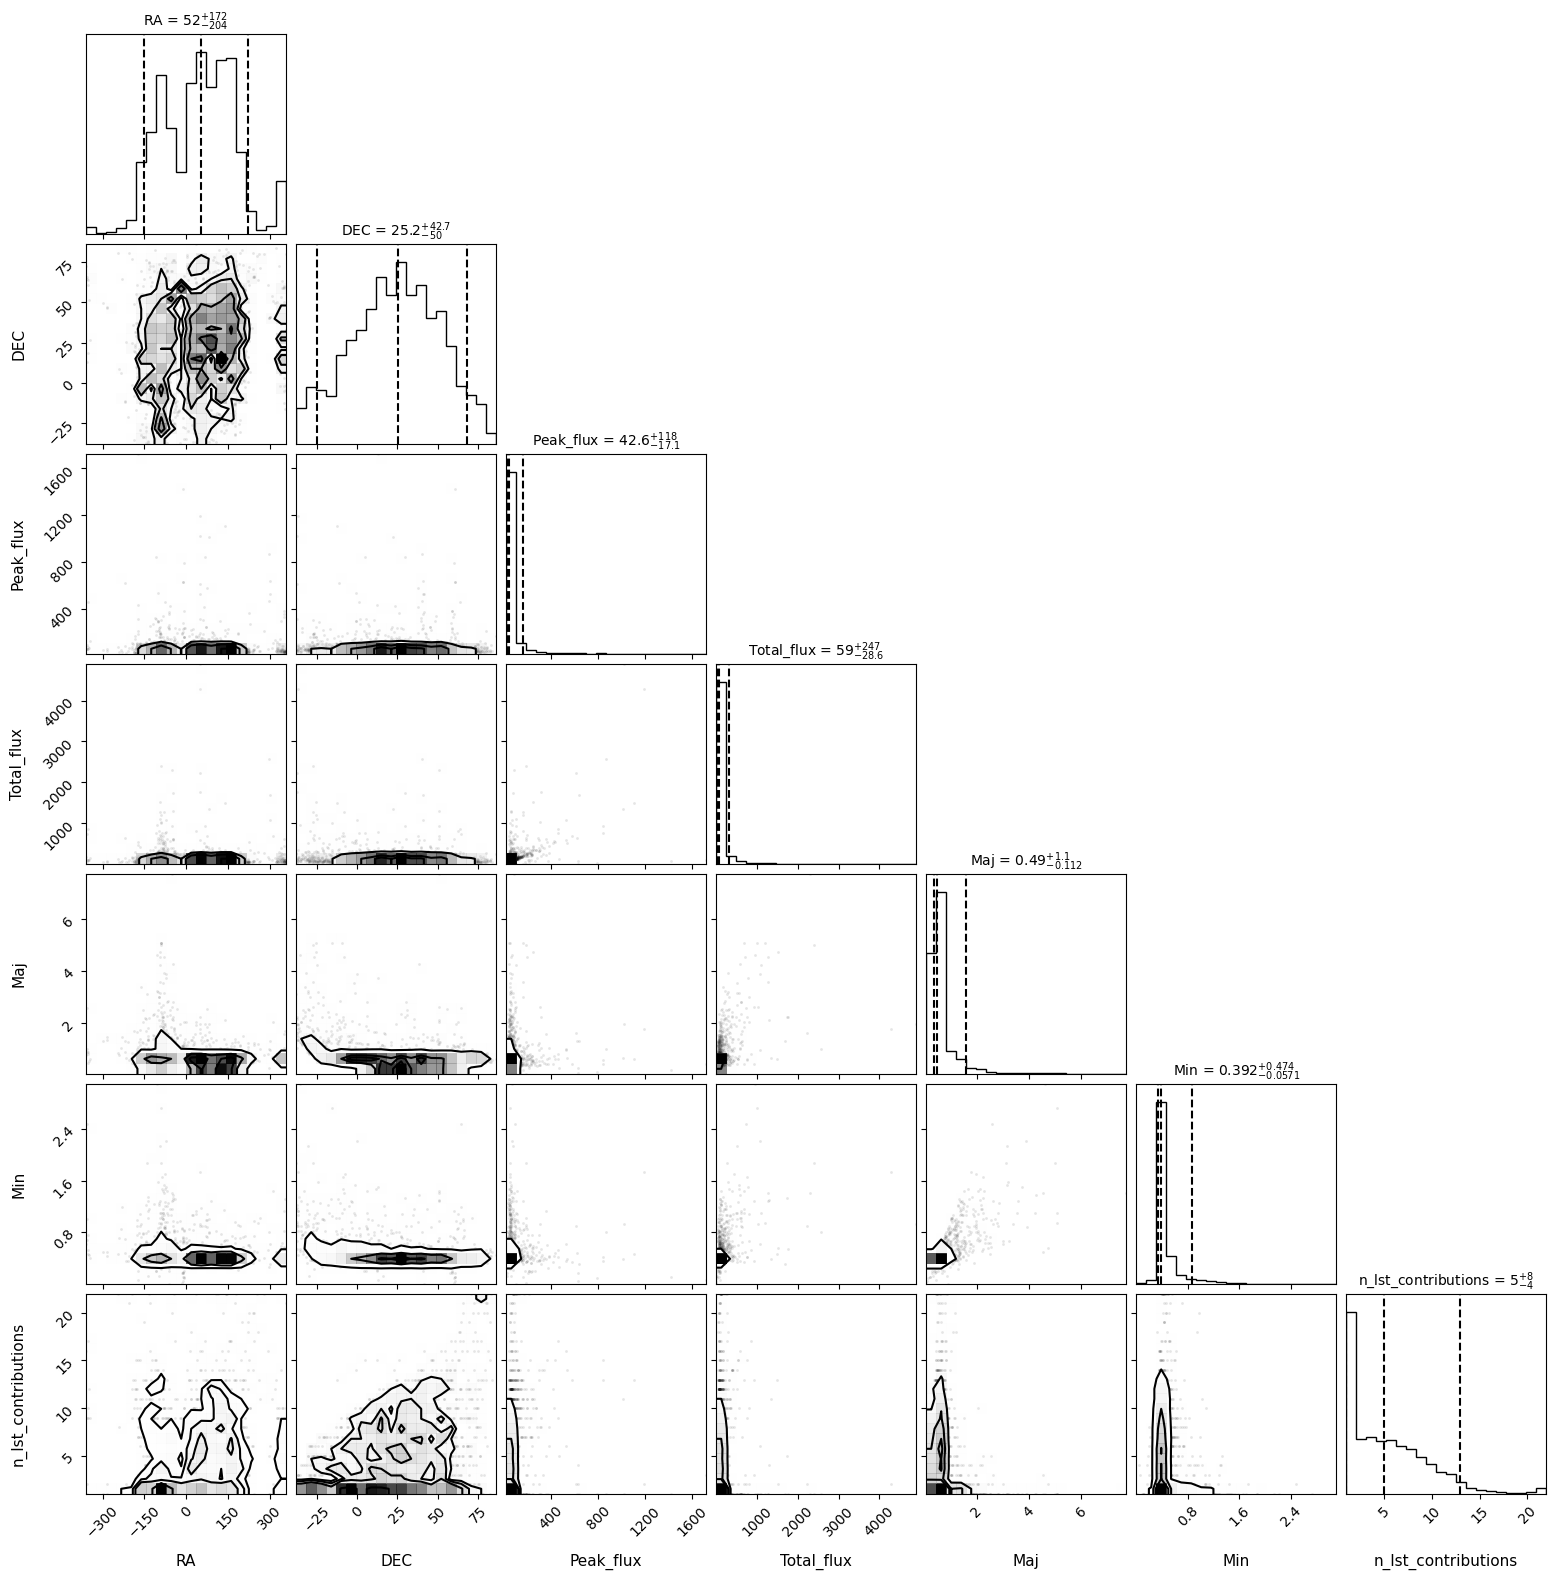

In [8]:
import corner
import matplotlib.pyplot as plt

cols = ["RA", "DEC", "Peak_flux", "Total_flux", "Maj", "Min", "n_lst_contributions"]

# drop NaNs; corner needs a clean numeric array
data = catalog[cols].dropna().to_numpy()

fig = corner.corner(
    data,
    labels=cols,
    quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 11},
)

plt.show()